# Image Emotion Detection using ResNet50

## Imports

In [16]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from collections import Counter


## Paths & Device

In [17]:
ROOT_DIR = r"C:\Users\USER\PycharmProjects\DSGP15_Project\ml-models\dataset\Dataset"

train_dir = os.path.join(ROOT_DIR, "Images", "Emotion", "train")
test_dir = os.path.join(ROOT_DIR, "Images", "Emotion", "test")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## Image Transformations

In [18]:
IMG_SIZE = 224
BATCH_SIZE = 16

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


## Dataset & DataLoader

In [19]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes:", train_dataset.classes)
num_classes = len(train_dataset.classes)


Classes: ['Happiness', 'Sadness']


## Handle Class Imbalance

In [20]:

class_counts = Counter(train_dataset.targets)
total_samples = sum(class_counts.values())

class_weights = [
    total_samples / class_counts[i]
    for i in range(len(class_counts))
]

class_weights = torch.tensor(class_weights).to(device)
print("Class weights:", class_weights)


Class weights: tensor([2., 2.])


## Handle Class Imbalance


In [ ]:
class_counts = Counter(train_dataset.targets)
total_samples = sum(class_counts.values())

class_weights = [
    total_samples / class_counts[i]
    for i in range(num_classes)
]

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)


## Load ResNet50

In [21]:
resnet = models.resnet50(pretrained=True)

# Set classifier for training
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)

resnet = resnet.to(device)


C:\Users\USER\PycharmProjects\DSGP15_Project\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\PycharmProjects\DSGP15_Project\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Loss Function & Optimizer

In [7]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(resnet.parameters(), lr=0.0002)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.5
)


## Training Loop

In [8]:
EPOCHS = 10
train_losses = []

for epoch in range(EPOCHS):
    resnet.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    scheduler.step()
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch + 1}/{EPOCHS}] - Loss: {epoch_loss:.4f}")


Epoch [1/10] - Loss: 0.5924
Epoch [2/10] - Loss: 0.5007
Epoch [3/10] - Loss: 0.4277
Epoch [4/10] - Loss: 0.2757
Epoch [5/10] - Loss: 0.1914
Epoch [6/10] - Loss: 0.1383
Epoch [7/10] - Loss: 0.0805
Epoch [8/10] - Loss: 0.0527
Epoch [9/10] - Loss: 0.0431
Epoch [10/10] - Loss: 0.0301


## Training Loss Plot

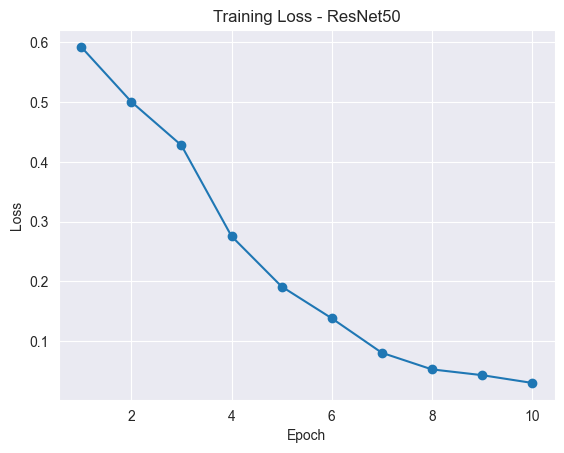

In [9]:
plt.figure()
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss - ResNet50")
plt.show()


## Evaluation Function

In [10]:
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs[:, 1].cpu().numpy())

    return np.array(y_true), np.array(y_pred), np.array(y_prob)


## Test Evaluation

In [11]:
y_true, y_pred, y_prob = evaluate_model(resnet, test_loader)

accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.2f}")


Test Accuracy: 0.74


## Confusion Matrix

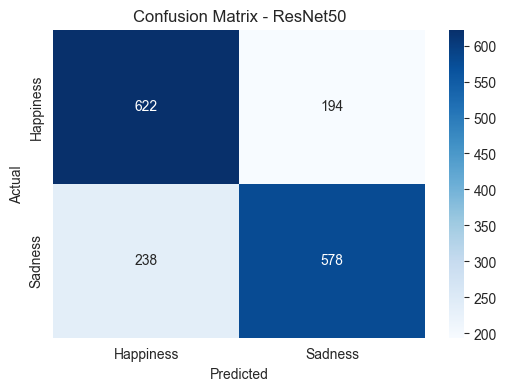

In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ResNet50")
plt.show()


## Classification Report

In [13]:
print("Classification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=train_dataset.classes
))


Classification Report:

              precision    recall  f1-score   support

   Happiness       0.72      0.76      0.74       816
     Sadness       0.75      0.71      0.73       816

    accuracy                           0.74      1632
   macro avg       0.74      0.74      0.74      1632
weighted avg       0.74      0.74      0.74      1632



## ROC Curve & AUC

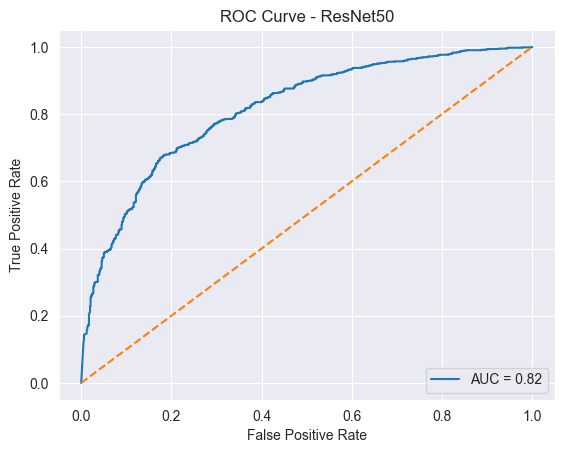

In [14]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ResNet50")
plt.legend(loc="lower right")
plt.show()


## Save Model

In [15]:
RESNET_MODEL_PATH = r"/ml-models/mood/notebooks/Pipeline/data/resnet50_emotion_model_cpu_optimized.pth"

torch.save(resnet.state_dict(), RESNET_MODEL_PATH)
print("ResNet50 model saved successfully")


Model saved successfully
